# 02 — Exploratory Data Analysis
## FairLend-Africa Research Project

Systematic exploration of the synthetic behavioral dataset.
Covers univariate distributions, bivariate relationships,
correlation structure, and a preliminary fairness audit
by demographic group.

Outputs saved to artifacts/eda/ for inclusion in the paper.

In [3]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 130

Path("../artifacts/eda").mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    "monthly_txn_count", "avg_txn_amount_usd", "wallet_balance_trend",
    "airtime_recharge_freq", "airtime_avg_amount_usd",
    "has_savings_account", "savings_consistency_score", "monthly_savings_usd",
    "has_prior_loan", "prior_loan_repayment_rate", "days_late_avg",
    "network_diversity_score", "bill_payment_regularity",
    "merchant_payment_count", "loan_amount_requested_usd", "loan_duration_weeks",
]
DEMOGRAPHIC_COLS = ["region", "gender", "age", "occupation"]
TARGET_COL = "repaid"

In [4]:
df = pd.read_csv("../data/synthetic/fairlend_dataset.csv")
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (10000, 21)

Dtypes:
region                           str
gender                           str
age                            int64
occupation                       str
monthly_txn_count              int64
avg_txn_amount_usd           float64
wallet_balance_trend         float64
airtime_recharge_freq          int64
airtime_avg_amount_usd       float64
has_savings_account            int64
savings_consistency_score    float64
monthly_savings_usd          float64
has_prior_loan                 int64
prior_loan_repayment_rate    float64
days_late_avg                float64
network_diversity_score      float64
bill_payment_regularity      float64
merchant_payment_count         int64
loan_amount_requested_usd    float64
loan_duration_weeks            int64
repaid                         int64
dtype: object


In [5]:
df.head(10)

,region,gender,age,occupation,monthly_txn_count,avg_txn_amount_usd,wallet_balance_trend,airtime_recharge_freq,airtime_avg_amount_usd,has_savings_account,...,monthly_savings_usd,has_prior_loan,prior_loan_repayment_rate,days_late_avg,network_diversity_score,bill_payment_regularity,merchant_payment_count,loan_amount_requested_usd,loan_duration_weeks,repaid
0,Southern Africa,Female,60,Self-employed,20,102.33,0.414,16,1.82,1,...,28.81,1,0.963,19.2,54.0,79.0,6,473.73,12,1
1,East Africa,Female,52,Self-employed,10,56.76,-0.479,14,1.76,0,...,0.00,1,0.552,15.9,34.0,69.0,2,121.91,8,0
2,Central Africa,Male,27,Salaried,4,51.68,-0.486,10,2.71,1,...,14.13,0,NaN,NaN,44.0,52.0,1,110.69,8,1
3,Southern Africa,Male,64,Farmer,9,29.82,-0.455,13,2.38,0,...,0.00,0,NaN,NaN,75.0,68.0,2,70.98,24,0
4,West Africa,Male,64,Farmer,8,37.34,-0.324,7,2.07,0,...,0.00,1,0.610,8.5,35.0,63.0,2,68.92,8,1
5,Central Africa,Male,19,Farmer,11,33.47,-0.064,11,1.51,1,...,21.45,1,0.708,31.8,65.0,53.0,3,322.86,8,1
6,Southern Africa,Male,19,Trader,8,13.09,0.230,10,1.55,1,...,21.04,1,0.770,9.4,63.0,48.0,5,39.00,4,1
7,Southern Africa,Prefer not to say,29,Salaried,28,155.49,0.025,18,2.25,0,...,0.00,1,0.653,9.7,25.0,89.0,10,76.43,24,1
8,West Africa,Male,55,Informal worker,14,81.76,0.346,13,2.84,1,...,19.78,1,0.599,0.8,46.0,70.0,3,45.43,8,1
9,East Africa,Male,46,Informal worker,20,79.33,-0.514,15,5.40,0,...,0.00,1,0.676,8.9,25.0,84.0,10,1369.10,4,0


### 1. Class distribution
The target variable `repaid` is binary.
A ~75% positive rate reflects realistic African MFI repayment rates
reported in microfinance literature (Ledgerwood, 1999; Dupas & Robinson, 2013).

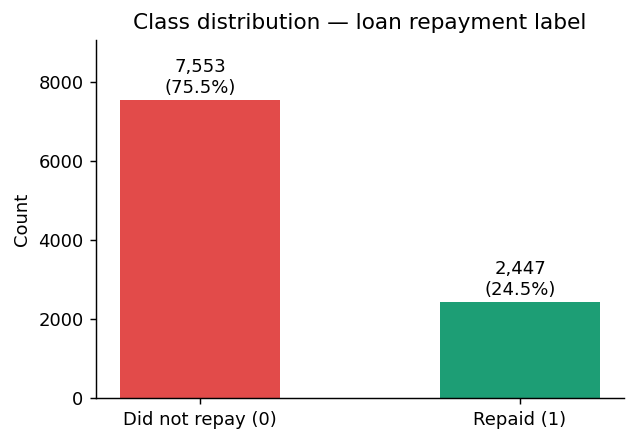

Class imbalance ratio: 3.09:1  (repaid:defaulted)


In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df[TARGET_COL].value_counts()
bars = ax.bar(
    ["Did not repay (0)", "Repaid (1)"],
    counts.values,
    color=["#E24B4A", "#1D9E75"],
    width=0.5
)
for bar, count in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{count:,}\n({count/len(df):.1%})",
        ha="center", va="bottom", fontsize=10
    )
ax.set_ylabel("Count")
ax.set_title("Class distribution — loan repayment label")
ax.set_ylim(0, counts.max() * 1.2)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../artifacts/eda/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Class imbalance ratio: {counts[1]/counts[0]:.2f}:1  (repaid:defaulted)")

### 2. Univariate distributions — continuous features
Histograms show the shape of each behavioral feature.
Right-skewed distributions (transaction amounts, savings)
are expected in mobile money data from low-income populations.

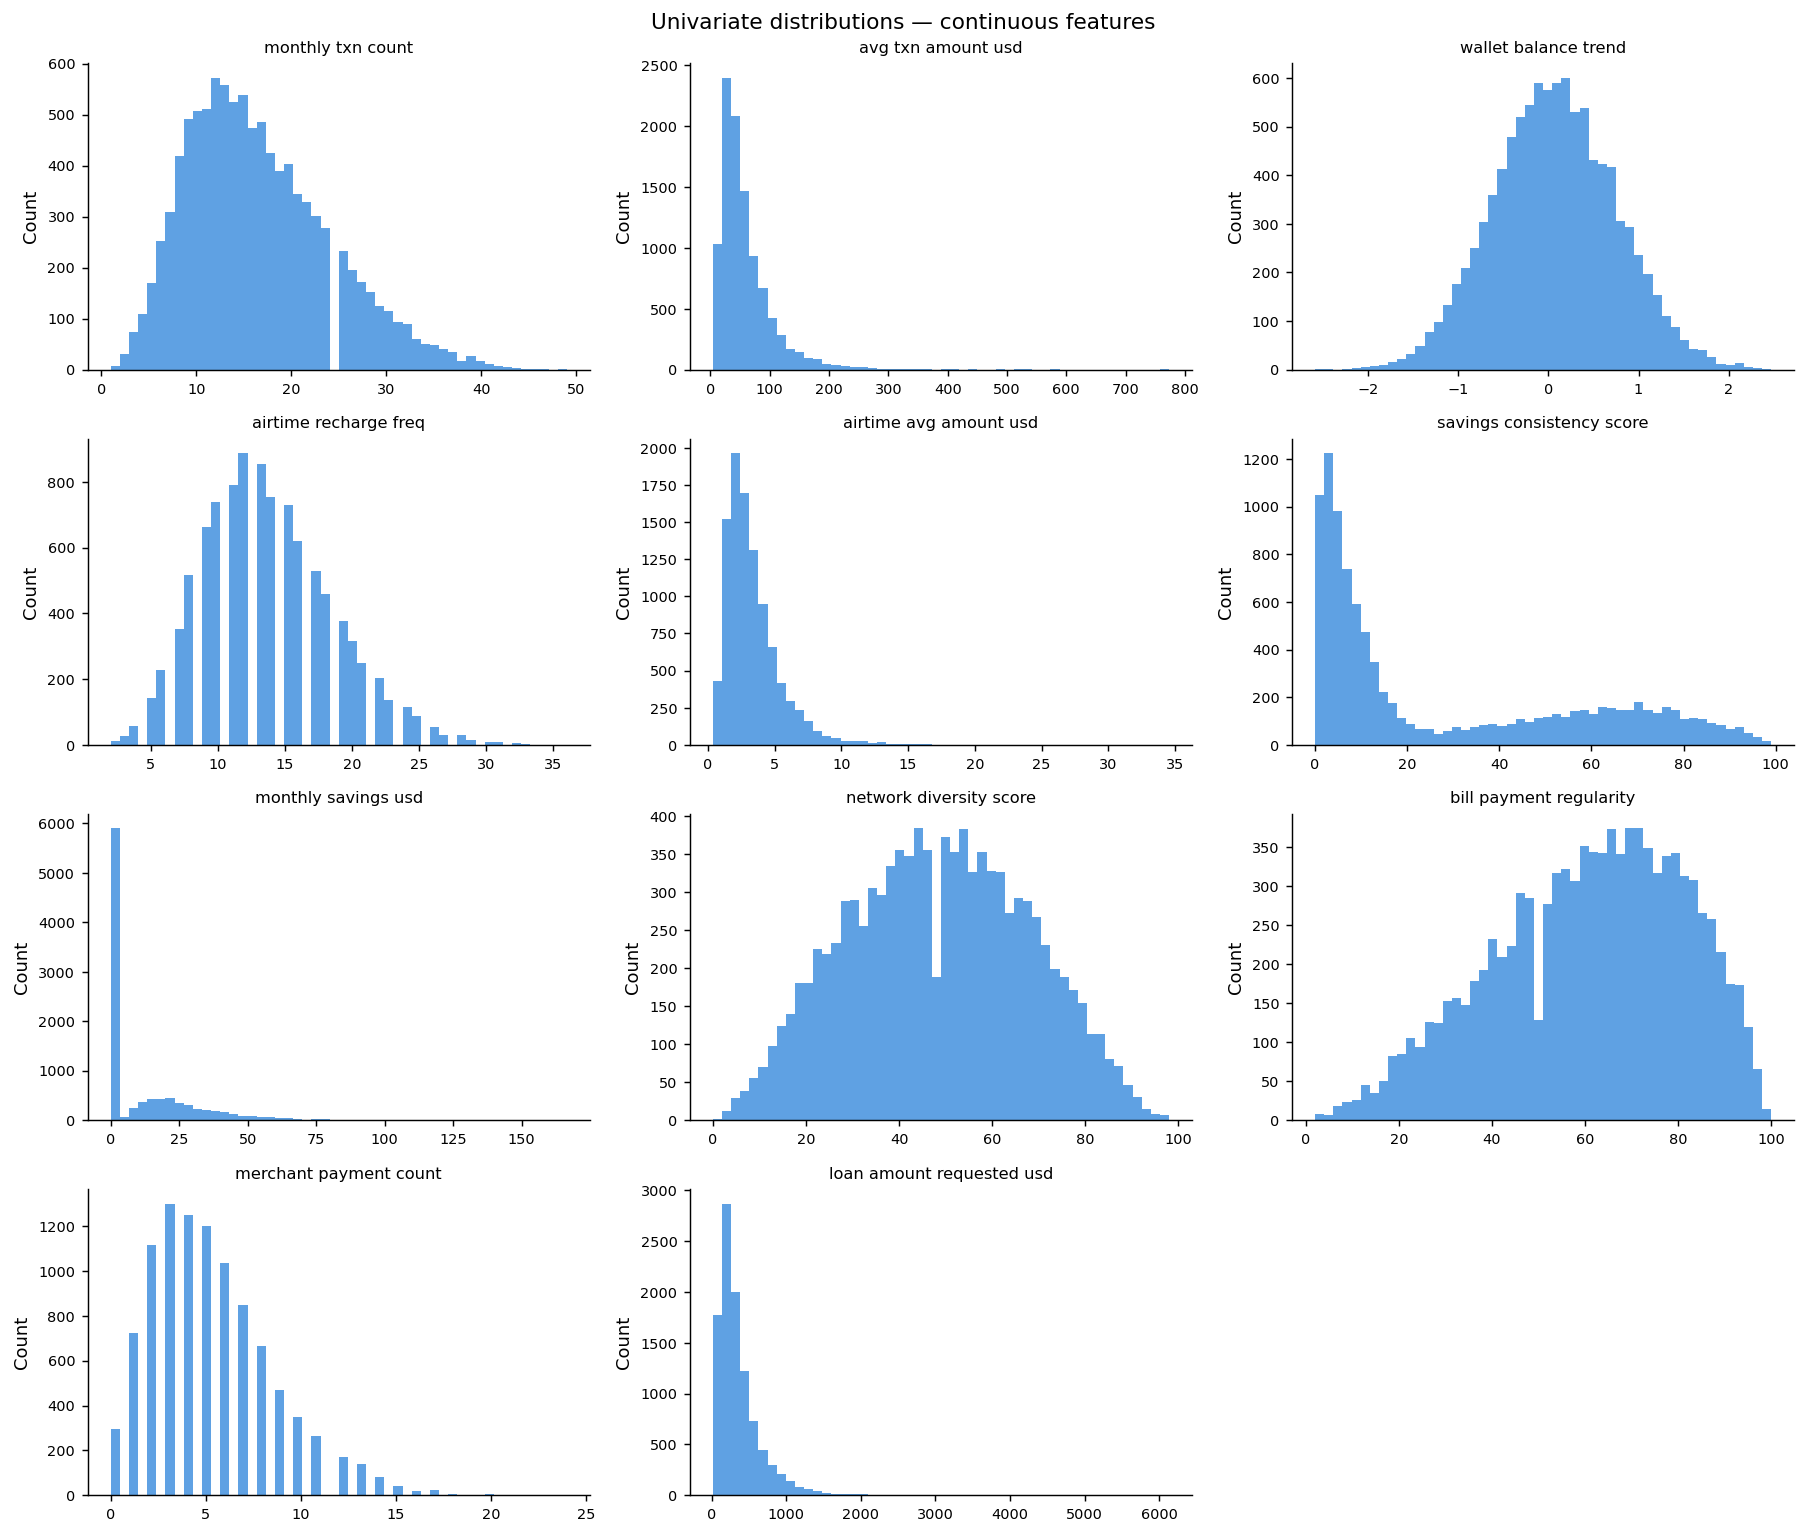

In [4]:
continuous_features = [
    "monthly_txn_count", "avg_txn_amount_usd", "wallet_balance_trend",
    "airtime_recharge_freq", "airtime_avg_amount_usd",
    "savings_consistency_score", "monthly_savings_usd",
    "network_diversity_score", "bill_payment_regularity",
    "merchant_payment_count", "loan_amount_requested_usd",
]

fig, axes = plt.subplots(4, 3, figsize=(14, 12))
axes = axes.flatten()

for i, feat in enumerate(continuous_features):
    ax = axes[i]
    ax.hist(df[feat].dropna(), bins=50, color="#378ADD", alpha=0.8, edgecolor="none")
    ax.set_title(feat.replace("_", " "), fontsize=9)
    ax.set_ylabel("Count")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)

# hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("Univariate distributions — continuous features", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/eda/univariate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 3. Bivariate distributions — features vs repayment label
Overlapping histograms show how each feature separates
repayers from defaulters. Visible separation indicates
predictive signal.

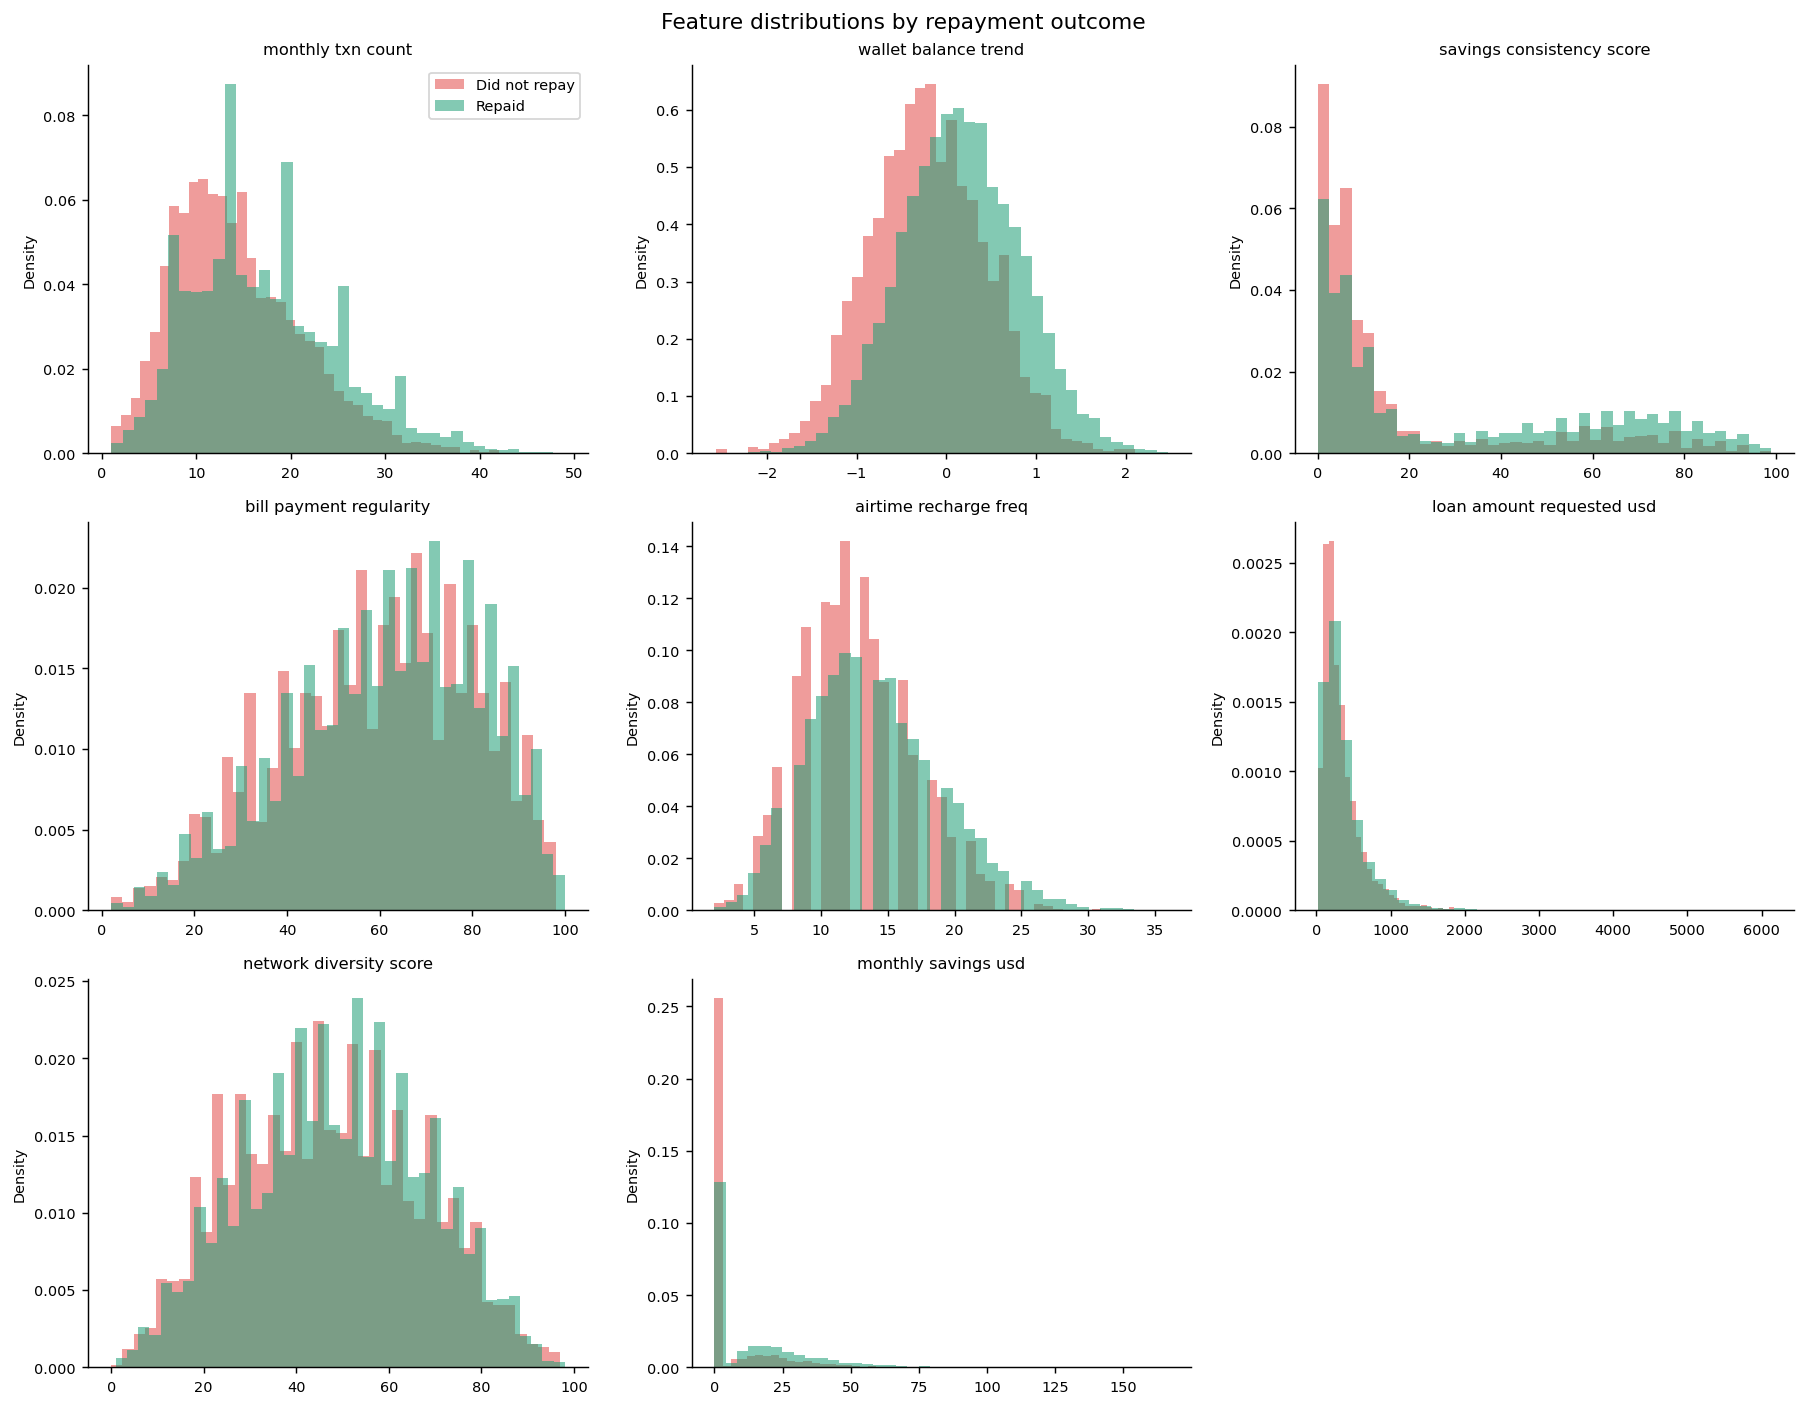

In [6]:
key_features = [
    "monthly_txn_count", "wallet_balance_trend",
    "savings_consistency_score", "bill_payment_regularity",
    "airtime_recharge_freq", "loan_amount_requested_usd",
    "network_diversity_score", "monthly_savings_usd",
]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    for label, color, name in [
        (0, "#E24B4A", "Did not repay"),
        (1, "#1D9E75", "Repaid")
    ]:
        subset = df[df[TARGET_COL] == label][feat].dropna()
        ax.hist(subset, bins=40, alpha=0.55, color=color,
                label=name, density=True, edgecolor="none")
    ax.set_title(feat.replace("_", " "), fontsize=9)
    ax.set_ylabel("Density", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=8)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].set_visible(False)

plt.suptitle("Feature distributions by repayment outcome", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/eda/bivariate_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. Correlation matrix
Pearson correlations across all features and the target variable.
Moderate inter-feature correlations are expected —
savings behavior naturally correlates with transaction volume.
High multicollinearity (r > 0.9) would be problematic;
none is expected here.

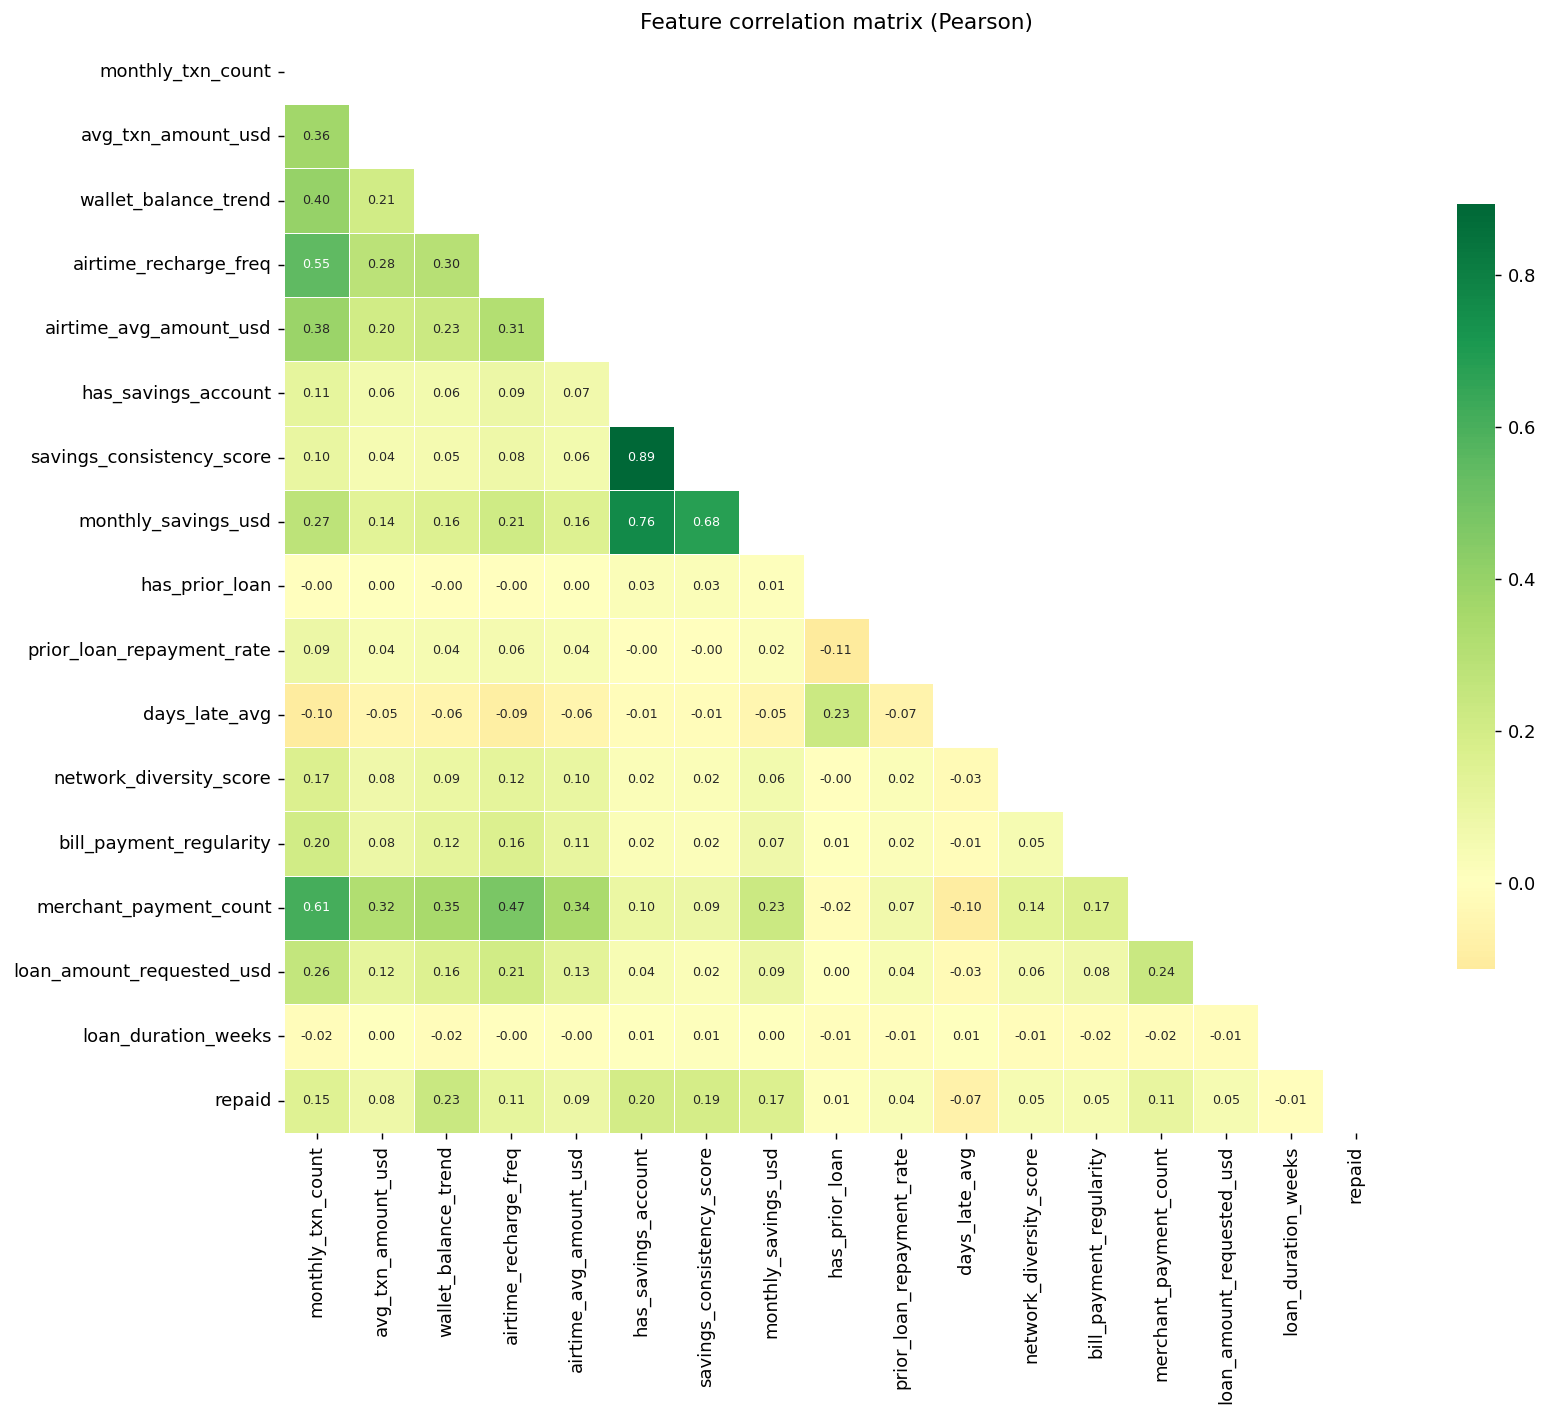

In [7]:
corr_df = df[FEATURE_COLS + [TARGET_COL]].fillna(
    df[FEATURE_COLS + [TARGET_COL]].median()
)
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, linewidths=0.3,
    ax=ax, annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Feature correlation matrix (Pearson)", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/eda/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
target_corr = corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

print("Feature correlations with repayment label:\n")
print(f"  {'Feature':<35} {'r':>8}   Direction")
print("  " + "-" * 55)
for feat, val in target_corr.items():
    direction = "↑ positive" if val > 0 else "↓ negative"
    print(f"  {feat:<35} {val:>+.4f}   {direction}")

Feature correlations with repayment label:

  Feature                                    r   Direction
  -------------------------------------------------------
  wallet_balance_trend                +0.2344   ↑ positive
  has_savings_account                 +0.1973   ↑ positive
  savings_consistency_score           +0.1935   ↑ positive
  monthly_savings_usd                 +0.1689   ↑ positive
  monthly_txn_count                   +0.1470   ↑ positive
  airtime_recharge_freq               +0.1144   ↑ positive
  merchant_payment_count              +0.1108   ↑ positive
  airtime_avg_amount_usd              +0.0859   ↑ positive
  avg_txn_amount_usd                  +0.0794   ↑ positive
  bill_payment_regularity             +0.0509   ↑ positive
  loan_amount_requested_usd           +0.0496   ↑ positive
  network_diversity_score             +0.0454   ↑ positive
  prior_loan_repayment_rate           +0.0352   ↑ positive
  has_prior_loan                      +0.0142   ↑ positive
  loan_durati

### 5. Missing value analysis
`prior_loan_repayment_rate` and `days_late_avg` are missing for
borrowers with no prior loan history. This is **Missing Not At Random
(MNAR)** — the absence itself is informative. These will be
median-imputed inside the sklearn Pipeline during model training.

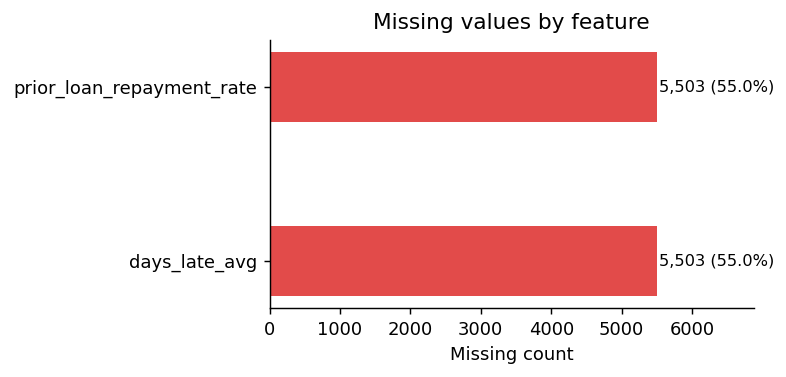


Missing = borrowers with no prior loan:
  has_prior_loan == 0: 5,503 rows


In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(6, 3))
bars = ax.barh(missing.index, missing.values, color="#E24B4A", height=0.4)
for bar, val in zip(bars, missing.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f"{val:,} ({val/len(df):.1%})",
            va="center", fontsize=9)
ax.set_xlabel("Missing count")
ax.set_title("Missing values by feature")
ax.set_xlim(0, missing.max() * 1.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../artifacts/eda/missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMissing = borrowers with no prior loan:")
print(f"  has_prior_loan == 0: {(df['has_prior_loan'] == 0).sum():,} rows")

### 6. Demographic distributions
Understanding who is in the dataset matters for
fairness analysis. These distributions affect whether
the model performs equally across demographic groups.

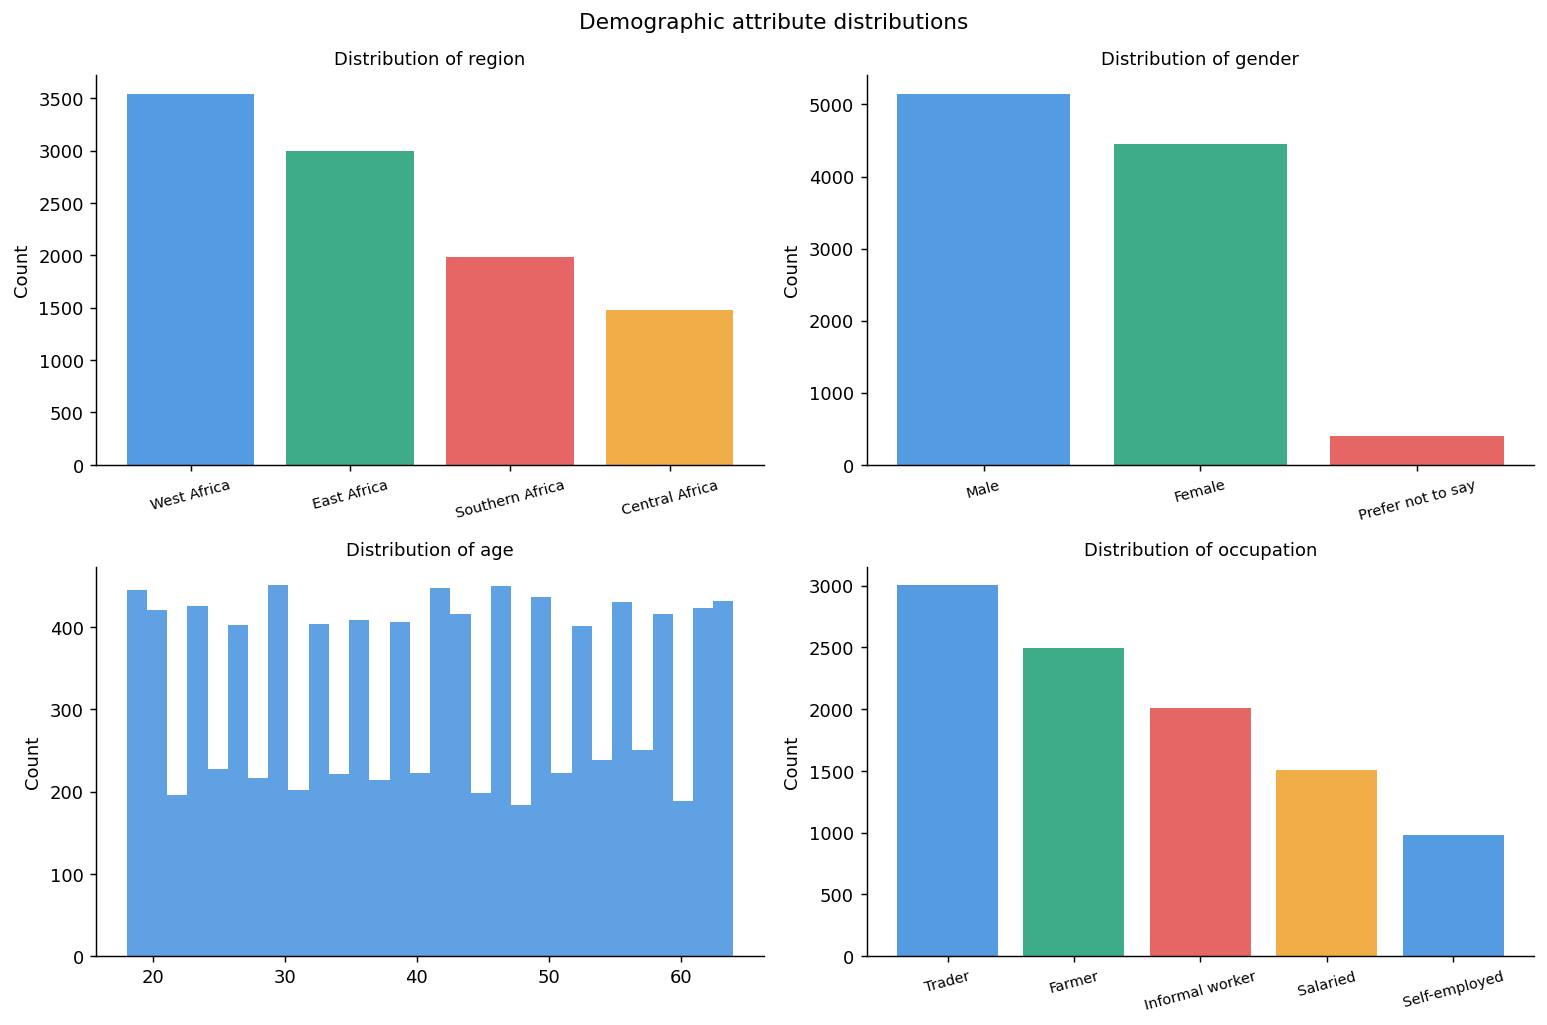

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

colors = ["#378ADD", "#1D9E75", "#E24B4A", "#EF9F27"]

for i, col in enumerate(DEMOGRAPHIC_COLS):
    ax = axes[i]
    if col == "age":
        ax.hist(df["age"], bins=30, color="#378ADD", alpha=0.8, edgecolor="none")
        ax.set_ylabel("Count")
    else:
        counts = df[col].value_counts()
        ax.bar(counts.index, counts.values, color=colors, alpha=0.85)
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.set_title(f"Distribution of {col}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Demographic attribute distributions", fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/eda/demographic_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

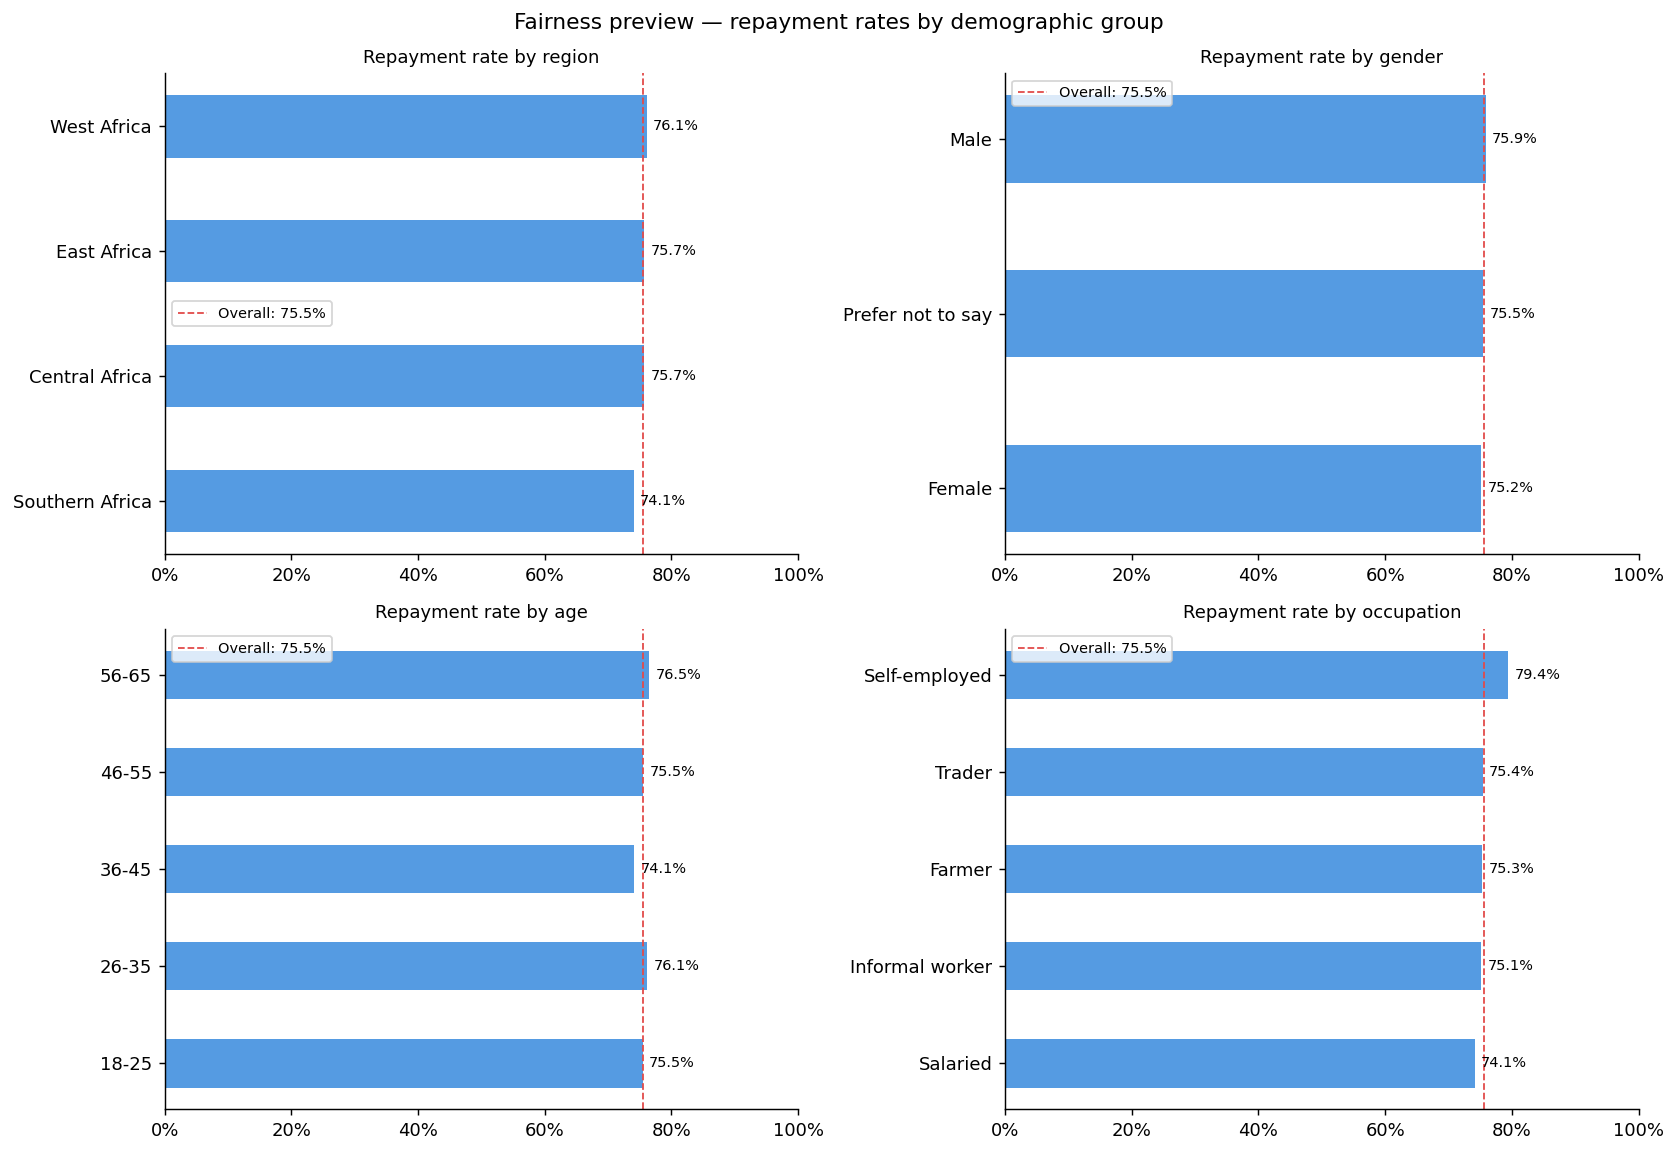

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

overall_rate = df[TARGET_COL].mean()

for i, col in enumerate(DEMOGRAPHIC_COLS):
    ax = axes[i]
    if col == "age":
        # bin age into groups
        df["age_group"] = pd.cut(df["age"], bins=[17,25,35,45,55,65],
                                  labels=["18-25","26-35","36-45","46-55","56-65"])
        rates = df.groupby("age_group", observed=True)[TARGET_COL].mean()
    else:
        rates = df.groupby(col)[TARGET_COL].mean().sort_values()

    bars = ax.barh(rates.index.astype(str), rates.values,
                   color="#378ADD", height=0.5, alpha=0.85)
    ax.axvline(overall_rate, color="#E24B4A", linestyle="--",
               linewidth=1, label=f"Overall: {overall_rate:.1%}")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_title(f"Repayment rate by {col}", fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, rates.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.1%}", va="center", fontsize=8)

plt.suptitle("Fairness preview — repayment rates by demographic group",
             fontsize=12)
plt.tight_layout()
plt.savefig("../artifacts/eda/fairness_preview.png", dpi=150, bbox_inches="tight")
plt.show()

## EDA Summary

| Finding | Implication |
|---|---|
| 75.5% positive class rate | Mild imbalance — address with `scale_pos_weight` |
| `wallet_balance_trend` highest correlation (+0.23) | Primary behavioral signal |
| Savings features cluster together (r ≈ 0.7–0.8) | Mild multicollinearity — monitor |
| 55% missing in prior loan features | MNAR — impute with median inside pipeline |
| Repayment rates vary by region (~3–5% spread) | Fairness analysis required in paper |
| No feature exceeds r = 0.25 with target | Task is genuinely difficult — realistic |